# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [1]:
from typing import Tuple

from matplotlib.figure import Figure
from pandas import DataFrame
from torch.distributions.constraints import dependent

from mlp.penalties import L1Penalty, L2Penalty, L1L2MixPenalty

ROOT = "/Users/matthewgiles/PycharmProjects/mlpractical"
FIGURE_PATH = f"{ROOT}/report/figures"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import logging
import sys
sys.path.append(ROOT)

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser

In [3]:
import os

# Set all the env variables
os.environ["MLP_DATA_DIR"] = os.path.join(ROOT, "data")

In [4]:


from mlp.layers import DropoutLayer


class CustomModel(MultipleLayerModel):
    
    def __init__(self, 
                input_dim=784, 
                output_dim=47,
                width=128,
                depth=2,
                reg=None, 
                coefficient=0.5, 
                coefficient2=0.5,
                rng=None,
                activation=None,
             ):
        
        # Set the model parameters
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.width = width
        self.depth = depth
        self.reg = reg
        self.coefficient = coefficient
        self.coefficient2 = coefficient2
        self.rng = rng
        
        # Weight initializers    
        self.weights_init = GlorotUniformInit(rng=self.rng)
        self.biases_init = ConstantInit(0.)
        
        self.penalty = None
        self.activation = activation
        
        if self.activation is None:
            self.activation = ReluLayer()
        
        # Ensure reg is lowercase for comparison
        if self.reg is not None:
            self.reg = self.reg.lower()
                
        if reg == "l1":
            self.penalty = L1Penalty(coefficient=self.coefficient)
        elif reg == "l2":
            self.penalty = L2Penalty(coefficient=self.coefficient)
        elif reg == "l1l2":
            self.penalty = L1L2MixPenalty(self.coefficient, self.coefficient2)
        
        # Build the model
        self.build()
        self.compile()
    
    def build(self):
        
        # Init the layers
        # Hidden layer 1
        layers = []
        
        for i in range(self.depth):
            
            is_input = (i == 0)
            is_output = (i == self.depth - 1)
            
            # Get the input width
            input_width = self.input_dim if is_input else self.width
            output_width = self.output_dim if is_output else self.width
            
            print("Affine({}, in={}, out={})".format(i+1, input_width, output_width))
            
            layers.append(AffineLayer(
                input_width, output_width,
                self.weights_init, self.biases_init, 
                weights_penalty=self.penalty, biases_penalty=None,
            ))
            layers.append(self.activation)
            
            if self.reg == "dropout" and not is_output:
                layers.append(DropoutLayer(incl_prob=self.coefficient))
        
        return super().__init__(layers)
    
    def compile(self, learning_rate=9e-4):
        self.error = CrossEntropySoftmaxError()
        self.learning_rule = AdamLearningRule(learning_rate=learning_rate)
        
    def fit(self, train_data, valid_data, num_epochs=100, stats_interval=1, notebook=True, gradients=False):

        # Return a pandas dataframe with all the info we are interested in
        optimiser = Optimiser(
            self, 
            self.error, 
            self.learning_rule, 
            train_data,
            valid_data,
            data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}, 
            notebook=notebook
        )
        
        # Train the model
        stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)
        
        # Get the info
        # Set the columns to the keys of info + keys
        out_df = pd.DataFrame(columns=list(self.info.keys()) + ["epoch"] + list(keys.keys()))
        
        for e in range(num_epochs):
            
            # Copy the info
            info = self.info.copy()
            info["epoch"] = e + 1
            
            # Loop through the keys and add all their info
            for key in keys:
                info[key] = stats[e, keys[key]]
                
            # Add to the dataframe
            # AttributeError: 'DataFrame' object has no attribute 'append' 
            # out_df = out_df.append(info, ignore_index=True)
            out_df = pd.concat([out_df, pd.DataFrame([info])], ignore_index=True)

        # Order by the epoch
        out_df = out_df.sort_values(by=["epoch"])
                
        # Get the gradient plot
        if gradients:
            
            # Plot the gradient flow
            grad_plot, grad_ax = optimiser.plot_grad_flow()
            
            return out_df, grad_plot
        else:
            return out_df
    
    @property
    def info(self):
        return {
            "input_dim": self.input_dim,
            "output_dim": self.output_dim,
            "width": self.width,
            "depth": self.depth,
            "reg": self.reg,
            "coefficient": self.coefficient,
            "coefficient2": self.coefficient2,
        }


In [5]:

class Plotter:

    @staticmethod
    def plot(df, name=None, x_axis="epoch"):
        
        # Plot the error and accuracy against the independent variable
        metrics = ["acc", "error"]
        names = ["Accuracy", "Error"]
        
        
        for metric, metric_name in zip(metrics, names):
            plt.figure(figsize=(8, 4))
            
            for ind_key in df[name].unique():
                
                # Plot across the epochs for the independent variable
                sub_df = df[df[name] == ind_key]
                
                datasets = ["train", "valid"]
                line_style = ["-", "--"]
                
                for ds, style in zip(datasets, line_style):
                    plt.plot(
                        sub_df[x_axis],
                        sub_df[f"{metric}({ds})"],
                        linestyle=style,
                        label=f"{name} {ind_key}({ds})"
                    )
        
            plt.xlabel("Epoch number")
            plt.ylabel(metric_name)
            plt.title(f"{metric_name} vs {name}")
            plt.legend(loc="best")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
            
            # Get the name 
            if name is None:
                name = f"curve_{name}"
                
            # The path we are saving
            path = os.path.join(FIGURE_PATH, f"{name}_{metric}.png")
            
            print("Saving figure to:", path)
            
            # Save the name of the figure
            plt.savefig(path, bbox_inches="tight")
            
            
    # 
            
    @staticmethod
    def print_latex_rows(df, cols=None):
        
        all_cols = cols + ["acc(valid)", "error(train)", "error(valid)"]
        
        # Get the final epoch
        final_epoch = df["epoch"].max()
        final_df = df[df["epoch"] == final_epoch]
        
        # Sort by the indepdent variable
        final_df = final_df.sort_values(by=cols)
        
        
        # Output the first row which is the col names
        
        # indepdent var & Val. Acc. & Train Error & Val. Error\\
        for _, row in final_df.iterrows():
            line = ""
            for i, col in enumerate(all_cols):
                if i == 0:
                    line += "& "
                else:
                    line += f"{row[col]:>7.3f}   "
            line += "\\\\"
            print(line)
        

In [6]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
N_EPOCHS = 100

# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

smooth_train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng, smooth_labels=True)
smooth_valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng, smooth_labels=True)

KeysView(<numpy.lib.npyio.NpzFile object at 0x1046cfca0>)
KeysView(<numpy.lib.npyio.NpzFile object at 0x156f48f10>)
KeysView(<numpy.lib.npyio.NpzFile object at 0x156f48340>)
KeysView(<numpy.lib.npyio.NpzFile object at 0x156f48a60>)


# Question 2:

In [7]:
widths = [128, 64, 32]

# The joined df
q2_df = pd.DataFrame()

for width in widths:
    
    # Build the model with the width
    model = CustomModel(
        width=width,
        depth=2,
    )
    model.compile(learning_rate=9e-4)
    
    # Train to get the info
    df = model.fit(
        train_data,
        valid_data,
        num_epochs=10
    )
    
    # Add to the df
    q2_df = pd.concat([q2_df, df], ignore_index=True)


Affine(1, in=784, out=128)
Affine(2, in=128, out=47)


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.6s to complete
    error(train)=1.58e+00, acc(train)=6.07e-01, error(valid)=1.63e+00, acc(valid)=5.95e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 8: 1.1s to complete
    error(train)=1.49e+00, acc(train)=6.30e-01, error(valid)=1.52e+00, acc(valid)=6.23e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 9: 1.0s to complete
    error(train)=1.47e+00, acc(train)=6.34e-01, error(valid)=1.50e+00, acc(valid)=6.27e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 10: 1.1s to complete
    error(train)=1.45e+00, acc(train)=6.37e-01, error(valid)=1.48e+00, acc(valid)=6.31e-01
/var/folders/p3/gzg9876x5cdf6httpsjkn3940000gn/T/ipykernel_34844/1958621172.py:119: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out_df = pd.concat([out_df, pd.DataFrame([info])], ignore_index=True)


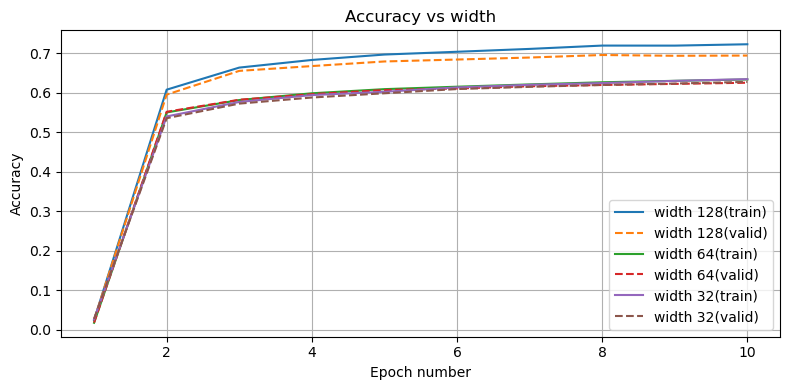

Saving figure to: /Users/matthewgiles/PycharmProjects/mlpractical/report/figures/width_acc.png


<Figure size 640x480 with 0 Axes>

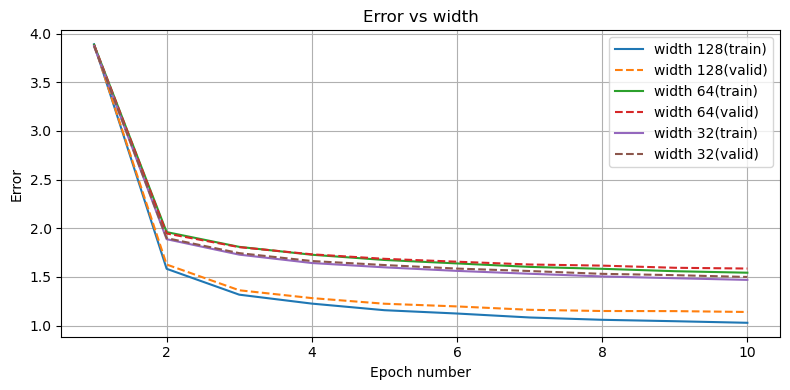

Saving figure to: /Users/matthewgiles/PycharmProjects/mlpractical/report/figures/width_error.png
&   0.627     1.469     1.499   \\
&   0.625     1.543     1.586   \\
&   0.694     1.028     1.139   \\


<Figure size 640x480 with 0 Axes>

In [8]:
# Plot the values
Plotter.plot(q2_df, name="width")
Plotter.print_latex_rows(q2_df, cols=["width"])

# Question 3:

In [ ]:
depths = [1, 2, 3]

# The joined df
q3_df = pd.DataFrame()

for depth in depths:
    
    # Build the model with the width
    model = CustomModel(
        depth=depth,
        width=128,
    )
    model.compile(learning_rate=9e-4)
    
    # Train to get the info
    df = model.fit(
        train_data,
        valid_data,
        num_epochs=N_EPOCHS
    )
    
    # Add to the df
    q3_df = pd.concat([q3_df, df], ignore_index=True)
    

Affine(1, in=784, out=47)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 1.4s to complete
    error(train)=2.15e+00, acc(train)=5.00e-01, error(valid)=2.17e+00, acc(valid)=4.99e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 35: 1.3s to complete
    error(train)=1.80e+00, acc(train)=5.62e-01, error(valid)=1.89e+00, acc(valid)=5.42e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 36: 2.1s to complete
    error(train)=1.81e+00, acc(train)=5.62e-01, error(valid)=1.90e+00, acc(valid)=5.41e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

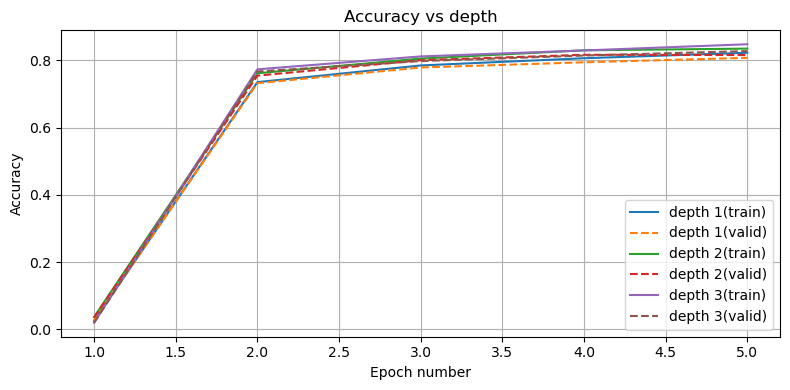

Saving figure to: /Users/matthewgiles/PycharmProjects/mlpractical/report/figures/depth_acc.png


<Figure size 640x480 with 0 Axes>

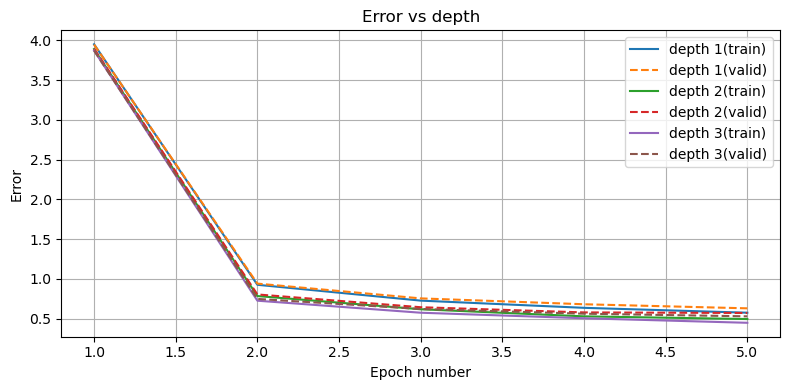

Saving figure to: /Users/matthewgiles/PycharmProjects/mlpractical/report/figures/depth_error.png
&   0.808     0.573     0.628   \\
&   0.816     0.494     0.570   \\
&   0.828     0.446     0.527   \\


<Figure size 640x480 with 0 Axes>

In [130]:
# Plot the values
Plotter.plot(q3_df, name="depth")
Plotter.print_latex_rows(q3_df, cols=["depth"])

# Question 4:

In [131]:
import pandas as pd

regs = {
    "baseline": [""],
    "dropout": [0.6, 0.7, 0.85, 0.97],
    "l1": [5e-4, 1e-3, 5e-3, 5e-2],
    "l2": [5e-4, 1e-3, 5e-3, 5e-2],
    # "dropout": [0.35, 0.55, 0.75, 0.95],
    # "l1": [1e-13, 1e-11, 1e-9, 1e-7, 1e-5, 1e-3],
    # "l2": [1e-13, 1e-11, 1e-9, 1e-7, 1e-5, 1e-3],
    "smooth": [""],
}


q4_df = pd.DataFrame()

for reg, params in regs.items():
    
    for param in params:
        
        model = CustomModel(
            reg=reg,
            coefficient=param,
        )
        model.compile(learning_rate=1e-4)
        
        # Whether we are training on smooth
        smooth = (reg == "smooth")
        
        # Train on the data
        df = model.fit(
            smooth_train_data if smooth else train_data,
            smooth_valid_data if smooth else valid_data,
            num_epochs=N_EPOCHS
        
        )
        
        # Add to the df
        q4_df = pd.concat([q4_df, df], ignore_index=True)
        

Adding hidden layer 0


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 4.4s to complete
    error(train)=1.43e+00, acc(train)=6.10e-01, error(valid)=1.43e+00, acc(valid)=6.08e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 3: 3.3s to complete
    error(train)=1.68e+00, acc(train)=7.06e-01, error(valid)=1.68e+00, acc(valid)=7.04e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 4.4s to complete
    error(train)=1.60e+00, acc(train)=7.29e-01, error(valid)=1.61e+00, acc(valid)=7.24e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 3.6s to complete
    error(train)=1.55e+00, acc(train)=7.44e-01, error(valid)=1.56e+00, acc(valid)=7.39e-01
/var/folders/p3/gzg9876x5cdf6httpsjkn3940000gn/T/ipykernel_21340/1396658095.py:118: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out_df = pd.concat([out_df, pd.DataFrame([info])], ignore_index=True)


In [ ]:

# A plot with dropout values along the x axis and their final epoch's loss



In [ ]:
# # --- L1/L2 plot ---
# l1l2_df = df[df["regularisation"].isin(["l1", "l2"])]
# 
# plt.figure(figsize=(6, 4))
# for reg in ["l1", "l2"]:
#     sub_df = l1l2_df[l1l2_df["regularisation"] == reg]
#     plt.plot(sub_df["parameter"], sub_df["valid_acc"], marker="o", label=f"{reg.upper()} Validation Accuracy")
#     plt.plot(sub_df["parameter"], sub_df["gen_gap"], marker="s", label=f"{reg.upper()} Gen Gap")
# 
# plt.xscale("log")
# plt.xlabel("Weight Penalty (log scale)")
# plt.ylabel("Metric Value")
# plt.title("Accuracy and Error by Weight Penalty")
# plt.legend()
# plt.grid(True, which="both")
# plt.tight_layout()
# plt.savefig(os.path.join(FIGURE_PATH, f"wd_plot.png"), dpi=300)
# plt.close()

In [132]:

# Loop through the different regs
for reg in regs.keys():
    
    # Get the sub df
    sub_df = q4_df[q4_df["reg"] == reg]
    
    print(f"--- LaTeX rows for {reg} ---")
    Plotter.print_latex_rows(sub_df, cols=["coefficient"])
    print("\n")


--- LaTeX rows for baseline ---
&   0.711     1.007     1.018   \\


--- LaTeX rows for dropout ---
&   0.692     1.484     1.492   \\
&   0.699     1.280     1.289   \\
&   0.709     1.089     1.098   \\
&   0.714     1.006     1.015   \\


--- LaTeX rows for l1 ---
&   0.698     1.070     1.075   \\
&   0.679     1.144     1.147   \\
&   0.597     1.522     1.522   \\
&   0.021     3.850     3.850   \\


--- LaTeX rows for l2 ---
&   0.711     1.004     1.012   \\
&   0.710     1.010     1.019   \\
&   0.698     1.066     1.073   \\
&   0.629     1.373     1.373   \\


--- LaTeX rows for smooth ---
&   0.724     1.603     1.614   \\




# Question 5:

In [133]:

l1s = [1e-11, 1e-9]
l2s = [1e-11, 1e-9]

q5_df = pd.DataFrame()

for l1 in l1s:
    for l2 in l2s:
        
        # Build the custom model
        model = CustomModel(
            reg="l1l2",
            coefficient=l1,
            coefficient2=l2,
        )
        model.compile(learning_rate=1e-4)
        
        # Train on the data
        df = model.fit(
            train_data,
            valid_data,
            num_epochs=N_EPOCHS
        )    
        
        # Add to the df
        q5_df = pd.concat([q5_df, df], ignore_index=True)


Adding hidden layer 0


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 6.0s to complete
    error(train)=1.43e+00, acc(train)=6.12e-01, error(valid)=1.43e+00, acc(valid)=6.10e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 3: 4.4s to complete
    error(train)=1.08e+00, acc(train)=6.96e-01, error(valid)=1.09e+00, acc(valid)=6.94e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 5.2s to complete
    error(train)=9.99e-01, acc(train)=7.18e-01, error(valid)=1.01e+00, acc(valid)=7.13e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 5.0s to complete
    error(train)=9.34e-01, acc(train)=7.33e-01, error(valid)=9.45e-01, acc(valid)=7.28e-01
/var/folders/p3/gzg9876x5cdf6httpsjkn3940000gn/T/ipykernel_21340/1396658095.py:118: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out_df = pd.concat([out_df, pd.DataFrame([info])], ignore_index=True)


In [134]:
Plotter.print_latex_rows(q5_df, cols=["coefficient", "coefficient2"])

&   0.000     0.711     0.995     1.008   \\
&   0.000     0.714     0.994     1.004   \\
&   0.000     0.714     0.993     1.004   \\
&   0.000     0.713     0.999     1.008   \\


# Question 6:

Adding hidden layer 0


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 5.7s to complete
    error(train)=3.85e+00, acc(train)=2.14e-02, error(valid)=3.85e+00, acc(valid)=1.88e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 4.5s to complete
    error(train)=3.84e+00, acc(train)=4.82e-02, error(valid)=3.85e+00, acc(valid)=4.48e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 3.7s to complete
    error(train)=3.84e+00, acc(train)=5.20e-02, error(valid)=3.84e+00, acc(valid)=4.78e-02
/var/folders/p3/gzg9876x5cdf6httpsjkn3940000gn/T/ipykernel_21340/1396658095.py:118: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out_df = pd.concat([out_df, pd.DataFrame([info])], ignore_index=True)


KeyError: 'custom_activation'

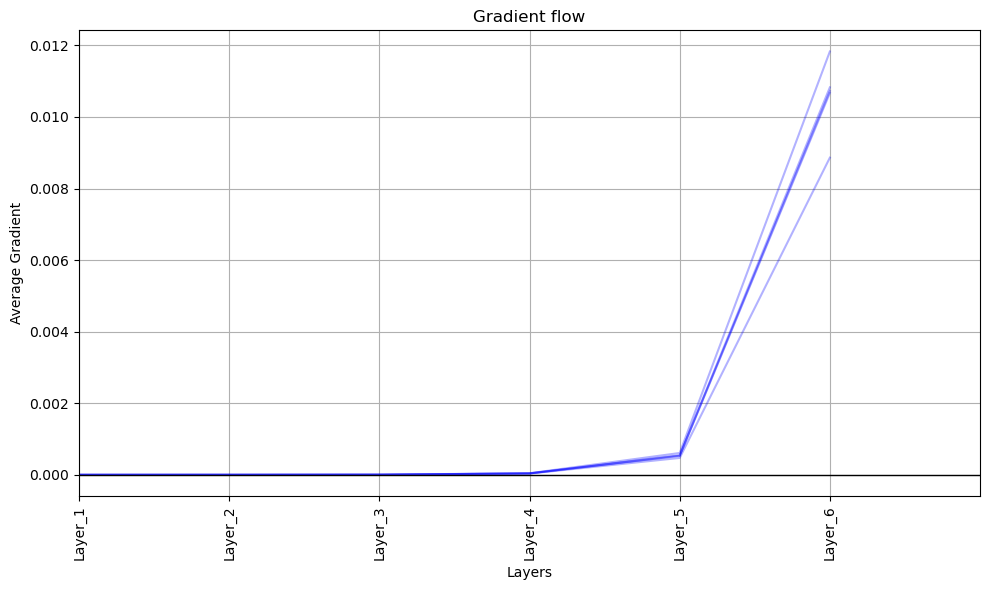

<Figure size 800x400 with 0 Axes>

In [135]:
# Build the custom model
model = CustomModel(
    activation=CustomActivationLayer(),
)
model.compile(learning_rate=1e-4)

# Train on the data
q6_df, grad_plot = model.fit(
    train_data,
    valid_data,
    gradients=True,
    num_epochs=N_EPOCHS
)

# Save the grad plot
Plotter.plot(q6_df, name="custom_activation")
grad_plot.savefig(os.path.join(FIGURE_PATH, f"custom_activation_grad_flow.png"), bbox_inches="tight")



In [ ]:
raise Exception("Stop here")